In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Amira/Downloads/inspection_results_with_ntas.csv")

# cuisine grouping copied from R logic
hypercategory = {
    "American": "American",
    "New American": "American",
    "Californian": "American",
    "Steakhouse": "American",
    "Barbecue": "American",
    "Hamburgers": "American",
    "Soul Food": "American",
    "Cajun": "American",
    "Creole": "American",
    "Creole/Cajun": "American",
    "Tex-Mex": "American",
    "Southwestern": "American",

    "Chinese": "East Asian",
    "Japanese": "East Asian",
    "Korean": "East Asian",
    "Chinese/Japanese": "East Asian",
    "Chinese/Cuban": "East Asian",

    "Indian": "South & Southeast Asian",
    "Thai": "South & Southeast Asian",
    "Southeast Asian": "South & Southeast Asian",
    "Bangladeshi": "South & Southeast Asian",
    "Pakistani": "South & Southeast Asian",
    "Filipino": "South & Southeast Asian",
    "Indonesian": "South & Southeast Asian",
    "Afghan": "South & Southeast Asian",
    "Asian/Asian Fusion": "South & Southeast Asian",

    "Mexican": "Latin American",
    "Latin American": "Latin American",
    "Caribbean": "Latin American",
    "Peruvian": "Latin American",
    "Brazilian": "Latin American",
    "Chilean": "Latin American",
    "Polynesian": "Latin American",
    "Hawaiian": "Latin American",

    "Italian": "European",
    "French": "European",
    "Spanish": "European",
    "English": "European",
    "German": "European",
    "Portuguese": "European",
    "Polish": "European",
    "Russian": "European",
    "Eastern European": "European",
    "Irish": "European",
    "Scandinavian": "European",
    "Czech": "European",
    "Basque": "European",
    "New French": "European",
    "Continental": "European",
    "Haute Cuisine": "European",
    "Australian": "European",

    "Mediterranean": "Mediterranean",
    "Greek": "Mediterranean",
    "Turkish": "Mediterranean",
    "Lebanese": "Mediterranean",
    "Moroccan": "Mediterranean",
    "Tapas": "Mediterranean",

    "Middle Eastern": "Middle Eastern",
    "Egyptian": "Middle Eastern",
    "Iranian": "Middle Eastern",
    "Armenian": "Middle Eastern",
    "Jewish/Kosher": "Middle Eastern",

    "African": "African",
    "Ethiopian": "African",

    "Pizza": "Dish-Type",
    "Sandwiches": "Dish-Type",
    "Chicken": "Dish-Type",
    "Seafood": "Dish-Type",
    "Hotdogs": "Dish-Type",
    "Hotdogs/Pretzels": "Dish-Type",
    "Bagels/Pretzels": "Dish-Type",
    "Pancakes/Waffles": "Dish-Type",
    "Salads": "Dish-Type",
    "Soups": "Dish-Type",

    "Coffee/Tea": "Beverages & Sweets",
    "Juice, Smoothies, Fruit Salads": "Beverages & Sweets",
    "Bottled Beverages": "Beverages & Sweets",
    "Donuts": "Beverages & Sweets",
    "Frozen Desserts": "Beverages & Sweets",
    "Bakery Products/Desserts": "Beverages & Sweets",
    "Nuts/Confectionary": "Beverages & Sweets",

    "Vegan": "Dietary Style",
    "Vegetarian": "Dietary Style",
    "Fruits/Vegetables": "Dietary Style",

    "Fusion": "Mixed/Uncategorized",
    "Sandwiches/Salads/Mixed Buffet": "Mixed/Uncategorized",
    "Soups/Salads/Sandwiches": "Mixed/Uncategorized",
    "Other": "Mixed/Uncategorized",
    "Not Listed/Not Applicable": "Mixed/Uncategorized",
    " ": "Mixed/Uncategorized"
}

# create grouped cuisine variable
df["hypercategory"] = df["cuisine"].map(hypercategory)

# remove missing score and missing/uncategorized cuisine groups
df = df.dropna(subset=["score", "hypercategory"])
df = df[df["hypercategory"] != "Mixed/Uncategorized"]

#  match  filtering
df = df[df["borough"] != "Staten Island"]
df = df[df["hypercategory"] != "Dietary Style"]

# create A vs not A outcome
# 1 = A grade 0 = not A
df["grade_binary"] = (df["score"] <= 13).astype(int)

# quick checks
print(df[["score", "borough", "cuisine", "hypercategory", "grade_binary"]].head())
print(df["grade_binary"].value_counts())
print(df["hypercategory"].value_counts())

df.head()

   score    borough    cuisine   hypercategory  grade_binary
1   23.0  Manhattan    Chinese      East Asian             0
2   12.0   Brooklyn  Caribbean  Latin American             1
3   51.0  Manhattan    Chinese      East Asian             0
4    0.0   Brooklyn    Chicken       Dish-Type             1
5   12.0  Manhattan   Japanese      East Asian             1
grade_binary
0    62517
1    39323
Name: count, dtype: int64
hypercategory
American                   19929
Beverages & Sweets         16768
East Asian                 16506
Latin American             14010
Dish-Type                  12905
European                    8960
South & Southeast Asian     7036
Middle Eastern              2791
Mediterranean               2396
African                      539
Name: count, dtype: int64


,Unnamed: 0,restaurant_id,score,borough,cuisine,inspection_date,action,violation_code,violation_category,inspection_type,NTA2020,Pop_1E,MdEWrkE,hypercategory,grade_binary
1,2,50118250,23.0,Manhattan,Chinese,05/01/2023,Violations were cited in the following area(s).,09B,COOLING & REFRIGERATION,Cycle Inspection / Initial Inspection,MN0701,68212.0,100000.0,East Asian,0
2,3,50017262,12.0,Brooklyn,Caribbean,06/10/2024,Violations were cited in the following area(s).,02B,HOT HOLDING,Cycle Inspection / Initial Inspection,BK0901,52273.0,43685.0,Latin American,1
3,4,50064099,51.0,Manhattan,Chinese,09/02/2025,Violations were cited in the following area(s).,09B,COOLING & REFRIGERATION,Cycle Inspection / Re-inspection,MN0301,38769.0,40632.0,East Asian,0
4,5,50054721,0.0,Brooklyn,Chicken,10/11/2022,Establishment re-opened by DOHMH.,NaN,NaN,Cycle Inspection / Reopening Inspection,BK1801,65280.0,48639.0,Dish-Type,1
5,6,40546234,12.0,Manhattan,Japanese,04/09/2024,Violations were cited in the following area(s).,02B,HOT HOLDING,Cycle Inspection / Initial Inspection,MN0502,21949.0,100000.0,East Asian,1


In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/Amira/Downloads/inspection_results_with_ntas.csv")

print(df.shape)

(113571, 13)


In [ ]:
#modeling dataframe 

model_df = df[[
    "grade_binary",
    "borough",
    "hypercategory",
    "violation_category",
    "inspection_type",
    "MdEWrkE",
    "Pop_1E"
]].dropna()


# grade_binary: response variable (Y)
# borough: restaurant borough/location
# hypercategory: grouped cuisine type
# violation_category: type of health violation
# inspection_type: type of inspection event
# MdEWrkE: neighborhood income/wealth variable
# Pop_1E: neighborhood population variable

#now get one hot encoding
#drop first to avoid mulitcolinaerity 
model_df = pd.get_dummies(
    model_df,
    columns=[
        "borough",
        "hypercategory",
        "violation_category",
        "inspection_type"
    ],
    drop_first=True
)
model_df.head()
model_df.shape
#curse of dimensionality :avodied !

#split data into x and y 
X = model_df.drop(columns=["grade_binary"])
y = model_df["grade_binary"]


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

(79314, 50)
(19829, 50)
(79314,)
(19829,)
Accuracy: 0.6603963891270361
AUC: 0.6783304560367254
Confusion matrix:
[[10209  2010]
 [ 4724  2886]]


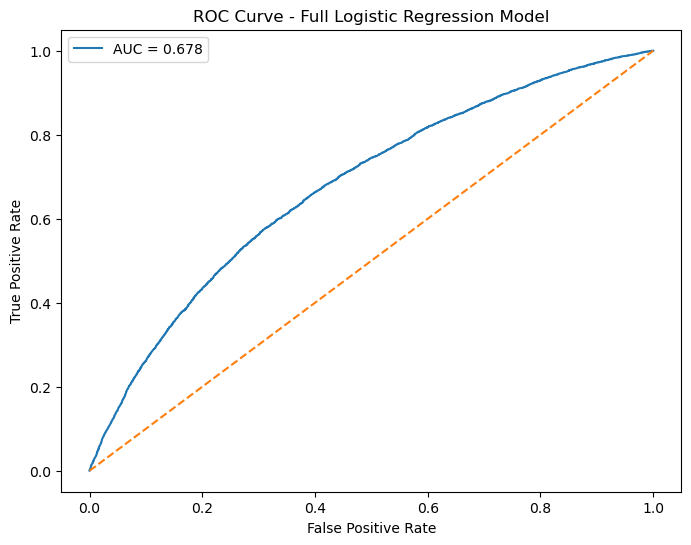

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Full Logistic Regression Model")
plt.legend()
plt.show()

In [15]:
# Full model
run_logistic_model(
    model_df,
    columns_to_remove=[],
    model_name="Full Model"
)


Full Model
X shape: (99143, 50)
Accuracy: 0.6603963891270361
AUC: 0.6783304560367254
Confusion matrix:
[[10209  2010]
 [ 4724  2886]]


In [16]:
# Remove neighborhood variables
run_logistic_model(
    model_df,
    columns_to_remove=["MdEWrkE", "Pop_1E"],
    model_name="Model Without Neighborhood Variables"
)


Model Without Neighborhood Variables
X shape: (99143, 48)
Accuracy: 0.6599929396338696
AUC: 0.6774204323440617
Confusion matrix:
[[10194  2025]
 [ 4717  2893]]


In [17]:
# Remove violation category columns
violation_cols = [col for col in model_df.columns if col.startswith("violation_category_")]

run_logistic_model(
    model_df,
    columns_to_remove=violation_cols,
    model_name="Model Without Violation Categories"
)


Model Without Violation Categories
X shape: (99143, 28)
Accuracy: 0.6254475767814817
AUC: 0.6203094231114401
Confusion matrix:
[[10998  1221]
 [ 6206  1404]]


In [18]:
# Remove inspection type columns
inspection_cols = [col for col in model_df.columns if col.startswith("inspection_type_")]

run_logistic_model(
    model_df,
    columns_to_remove=inspection_cols,
    model_name="Model Without Inspection Type"
)


Model Without Inspection Type
X shape: (99143, 36)
Accuracy: 0.6533360229966211
AUC: 0.661017421974502
Confusion matrix:
[[10263  1956]
 [ 4918  2692]]


In [19]:
# Remove both violation categories and inspection type
run_logistic_model(
    model_df,
    columns_to_remove=violation_cols + inspection_cols,
    model_name="Model Without Violations and Inspection Type"
)


Model Without Violations and Inspection Type
X shape: (99143, 14)
Accuracy: 0.6200514398103787
AUC: 0.5941133232221979
Confusion matrix:
[[11733   486]
 [ 7048   562]]


In [20]:
from sklearn.linear_model import LogisticRegression

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)

# predictions
y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

# evaluation
print("LASSO Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("AUC:", roc_auc_score(y_test, y_prob_lasso))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lasso))


feature_names = X_train.columns

coefficients = lasso_model.named_steps["logreg"].coef_[0]

lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

lasso_results["Abs_Coefficient"] = abs(lasso_results["Coefficient"])

lasso_results = lasso_results.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print(lasso_results.head(20))

c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


LASSO Logistic Regression
Accuracy: 0.6601946643804528
AUC: 0.6781456551960879
Confusion matrix:
[[10203  2016]
 [ 4722  2888]]
                                              Feature  Coefficient  \
27                    violation_category_PEST CONTROL    -0.434700   
37   inspection_type_Cycle Inspection / Re-inspection     0.362650   
36  inspection_type_Cycle Inspection / Initial Ins...     0.262064   
14                    violation_category_COLD HOLDING    -0.249219   
6                    hypercategory_Beverages & Sweets     0.248121   
5                              hypercategory_American     0.226077   
26                      violation_category_PERMIT/FPC    -0.217987   
21                 violation_category_HANDWASH/TOILET    -0.202786   
22                     violation_category_HOT HOLDING    -0.195435   
20                      violation_category_HACCP PLAN    -0.183254   
7                             hypercategory_Dish-Type     0.151036   
33               violation_categ

(79412, 50)
(19731, 50)
(79412,)
(19731,)
Grouped Split Logistic Regression
Accuracy: 0.6586082813846231
AUC: 0.6841626656717933
Confusion matrix:
[[10005  1959]
 [ 4777  2990]]


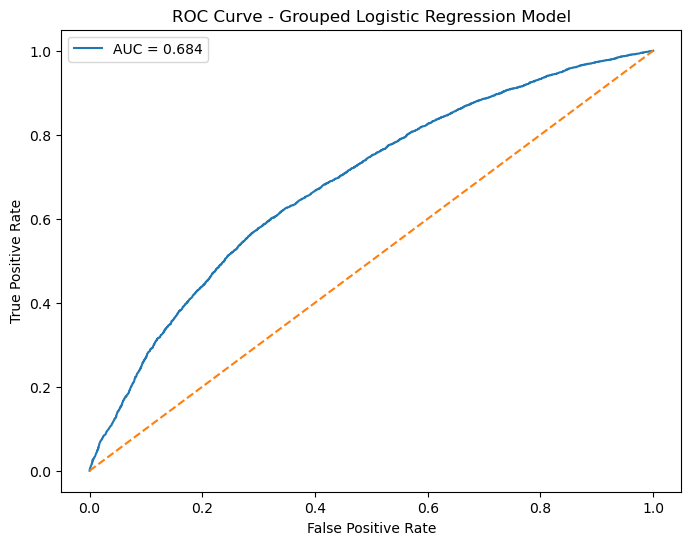

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# keep restaurant_id only for splitting
grouped_df = df[[
    "restaurant_id",
    "grade_binary",
    "borough",
    "hypercategory",
    "violation_category",
    "inspection_type",
    "MdEWrkE",
    "Pop_1E"
]].dropna()

# one-hot encode predictors
grouped_model_df = pd.get_dummies(
    grouped_df,
    columns=[
        "borough",
        "hypercategory",
        "violation_category",
        "inspection_type"
    ],
    drop_first=True
)

# separate X y
groups = grouped_model_df["restaurant_id"]

X_grouped = grouped_model_df.drop(columns=["restaurant_id", "grade_binary"])
y_grouped = grouped_model_df["grade_binary"]

# split by restaurant_id
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=62
)

train_idx, test_idx = next(gss.split(X_grouped, y_grouped, groups=groups))

X_train, X_test = X_grouped.iloc[train_idx], X_grouped.iloc[test_idx]
y_train, y_test = y_grouped.iloc[train_idx], y_grouped.iloc[test_idx]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# model
grouped_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

grouped_logistic_model.fit(X_train, y_train)

# predictions
y_pred = grouped_logistic_model.predict(X_test)
y_prob = grouped_logistic_model.predict_proba(X_test)[:, 1]

# evaluation
print("Grouped Split Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Grouped Logistic Regression Model")
plt.legend()
plt.show()

(14747, 16)
(3687, 16)
(14747,)
(3687,)
Accuracy: 0.887713588283157
AUC: 0.9469403775238233
Confusion matrix:
[[1522  274]
 [ 140 1751]]


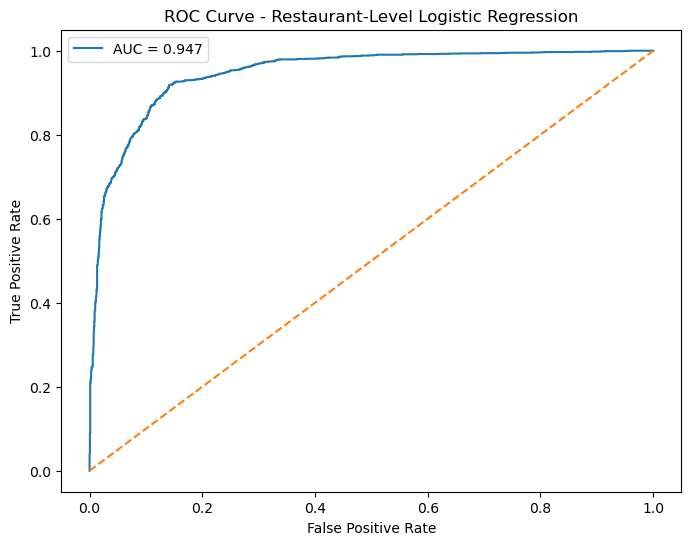

,grade_binary,num_inspections,num_violations,MdEWrkE,Pop_1E,borough_Brooklyn,borough_Manhattan,borough_Queens,hypercategory_American,hypercategory_Beverages & Sweets,hypercategory_Dish-Type,hypercategory_East Asian,hypercategory_European,hypercategory_Latin American,hypercategory_Mediterranean,hypercategory_Middle Eastern,hypercategory_South & Southeast Asian
0,0,2,6,46910.0,22818.0,False,False,False,False,True,False,False,False,False,False,False,False
1,0,2,6,62361.0,44491.0,True,False,False,False,False,True,False,False,False,False,False,False
2,1,1,3,50478.0,45910.0,True,False,False,False,True,False,False,False,False,False,False,False
3,1,1,2,100000.0,54062.0,False,True,False,True,False,False,False,False,False,False,False,False
4,1,1,2,41795.0,52480.0,True,False,False,False,False,True,False,False,False,False,False,False


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# redo the whole thing obersatiosn in each row

restaurant_df = df.groupby("restaurant_id").agg(

    avg_score=("score", "mean"),

    num_inspections=("inspection_date", "nunique"),

    num_violations=("violation_category", "count"),

    borough=("borough", "first"),

    hypercategory=("hypercategory", "first"),

    MdEWrkE=("MdEWrkE", "first"),

    Pop_1E=("Pop_1E", "first")

).reset_index()

# response varibael

restaurant_df["grade_binary"] = (
    restaurant_df["avg_score"] <= 13
).astype(int)

#datafraem

model_df_restaurant = restaurant_df[[
    "grade_binary",
    "borough",
    "hypercategory",
    "num_inspections",
    "num_violations",
    "MdEWrkE",
    "Pop_1E"
]].dropna()

#onehotencdoidng

model_df_restaurant = pd.get_dummies(
    model_df_restaurant,
    columns=[
        "borough",
        "hypercategory"
    ],
    drop_first=True
)

# assing x and y 

X = model_df_restaurant.drop(columns=["grade_binary"])
y = model_df_restaurant["grade_binary"]

# split tets train validate

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# fit the model ensusinrg there is scaling and standrdaizing

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train)

# predict 

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

#evaluate the mdeol using AUC

print("Accuracy:", accuracy_score(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# cretae a ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}"
)

# random guessing line to compare to 
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Restaurant-Level Logistic Regression")

plt.legend()

plt.show()

model_df_restaurant.head()

(14747, 39)
(3687, 39)
(14747,)
(3687,)
Accuracy: 0.9259560618388935
AUC: 0.971911993159486
Confusion matrix:
[[1633  163]
 [ 110 1781]]


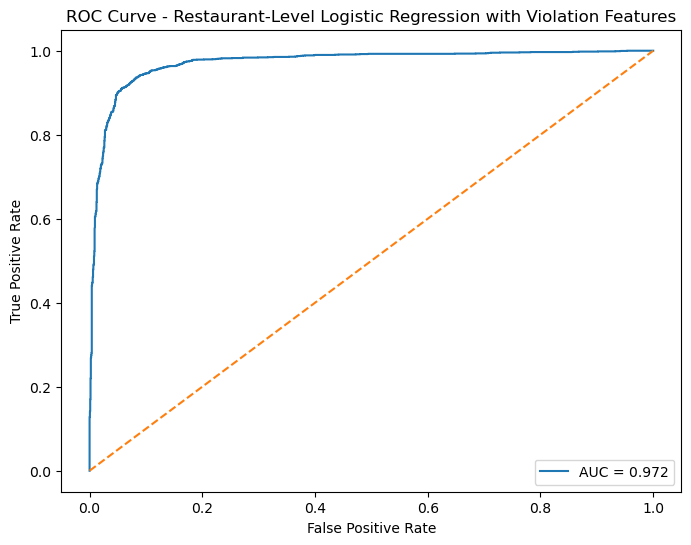

,num_inspections,num_violations,MdEWrkE,Pop_1E,violation_ADULTERATED,violation_COLD HOLDING,violation_CONTAMINATION,violation_COOKING,violation_COOLING & REFRIGERATION,violation_FOOD PROTECTION,...,borough_Queens,hypercategory_American,hypercategory_Beverages & Sweets,hypercategory_Dish-Type,hypercategory_East Asian,hypercategory_European,hypercategory_Latin American,hypercategory_Mediterranean,hypercategory_Middle Eastern,hypercategory_South & Southeast Asian
0,2,6,46910.0,22818.0,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
1,2,6,62361.0,44491.0,False,True,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,1,3,50478.0,45910.0,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,1,2,100000.0,54062.0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,1,2,41795.0,52480.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# violation dummy vairnels

violation_dummies = pd.get_dummies(
    df["violation_category"],
    prefix="violation"
)

violation_dummies["restaurant_id"] = df["restaurant_id"]

violation_features = violation_dummies.groupby("restaurant_id").max().reset_index()

# new dataframe
restaurant_df = df.groupby("restaurant_id").agg(
    avg_score=("score", "mean"),
    num_inspections=("inspection_date", "nunique"),
    num_violations=("violation_category", "count"),
    borough=("borough", "first"),
    hypercategory=("hypercategory", "first"),
    MdEWrkE=("MdEWrkE", "first"),
    Pop_1E=("Pop_1E", "first")
).reset_index()

# merge viilatons 

restaurant_df = restaurant_df.merge(
    violation_features,
    on="restaurant_id",
    how="left"
)

#response

restaurant_df["grade_binary"] = (restaurant_df["avg_score"] <= 13).astype(int)

# datatframe

model_df = restaurant_df.drop(columns=["restaurant_id", "avg_score"])

model_df = pd.get_dummies(
    model_df,
    columns=["borough", "hypercategory"],
    drop_first=True
)

# Fill missing violation indicators with 0
violation_cols = [col for col in model_df.columns if col.startswith("violation_")]
model_df[violation_cols] = model_df[violation_cols].fillna(0)

# Drop remaining missing values, likely from neighborhood variables
model_df = model_df.dropna()

# x and y assinged 

X = model_df.drop(columns=["grade_binary"])
y = model_df["grade_binary"]

# split theh dtaa and train

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# new mdoel again

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train)

# predict with the mdoel 

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# evaluate he mdoel

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

#plot roc curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Restaurant-Level Logistic Regression with Violation Features")
plt.legend()
plt.show()
model_df.head()


In [ ]:
#check for fetaure impaticne

feature_names = X_train.columns

coefficients = logistic_model.named_steps["logreg"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print(coef_df.head(20))

                                            Feature  Coefficient  \
1                                    num_violations    -6.049211   
0                                   num_inspections     2.749672   
17                             violation_PERMIT/FPC    -0.891081   
5                            violation_COLD HOLDING    -0.780909   
13                            violation_HOT HOLDING    -0.734153   
12                        violation_HANDWASH/TOILET    -0.645314   
24                      violation_UNAPPROVED SOURCE    -0.534502   
18                           violation_PEST CONTROL    -0.501794   
11                             violation_HACCP PLAN    -0.489152   
9                         violation_FOOD PROTECTION    -0.371414   
19                               violation_PLUMBING     0.266566   
6                           violation_CONTAMINATION    -0.232876   
20                  violation_REDUCE OXYGEN PACKAGE    -0.207237   
10                           violation_FOOD WORK

In [5]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

print("LASSO Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("AUC:", roc_auc_score(y_test, y_prob_lasso))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lasso))

LASSO Logistic Regression
Accuracy: 0.9254136154054787
AUC: 0.9719105209414186
Confusion matrix:
[[1631  165]
 [ 110 1781]]


c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
# check for loasso ftruar imptortance

feature_names = X_train.columns

coefficients = lasso_model.named_steps["logreg"].coef_[0]

lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

lasso_results["Abs_Coefficient"] = abs(lasso_results["Coefficient"])

lasso_results = lasso_results.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print(lasso_results.head(20))

                                            Feature  Coefficient  \
1                                    num_violations    -6.212038   
0                                   num_inspections     2.802394   
17                             violation_PERMIT/FPC    -0.889845   
5                            violation_COLD HOLDING    -0.775262   
13                            violation_HOT HOLDING    -0.728495   
12                        violation_HANDWASH/TOILET    -0.641740   
24                      violation_UNAPPROVED SOURCE    -0.533951   
11                             violation_HACCP PLAN    -0.485050   
18                           violation_PEST CONTROL    -0.477242   
9                         violation_FOOD PROTECTION    -0.361564   
19                               violation_PLUMBING     0.281582   
6                           violation_CONTAMINATION    -0.226294   
20                  violation_REDUCE OXYGEN PACKAGE    -0.206569   
10                           violation_FOOD WORK

In [ ]:
# chcek lasso importance again

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)

# predictions
y_pred_lasso = lasso_model.predict(X_test)

y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

# evaluation
print("LASSO Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_lasso))

print("AUC:", roc_auc_score(y_test, y_prob_lasso))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lasso))

# lasso fetaure improancne

feature_names = X_train.columns

coefficients = lasso_model.named_steps["logreg"].coef_[0]

lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

lasso_results["Abs_Coefficient"] = abs(lasso_results["Coefficient"])

lasso_results = lasso_results.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print(lasso_results.head(25))

LASSO Logistic Regression
Accuracy: 0.9243287225386493
AUC: 0.9718782793657448
Confusion matrix:
[[1628  168]
 [ 111 1780]]
                                            Feature  Coefficient  \
1                                    num_violations    -5.885253   
0                                   num_inspections     2.621633   
17                             violation_PERMIT/FPC    -0.844430   
5                            violation_COLD HOLDING    -0.735915   
13                            violation_HOT HOLDING    -0.690738   
12                        violation_HANDWASH/TOILET    -0.606115   
24                      violation_UNAPPROVED SOURCE    -0.497450   
18                           violation_PEST CONTROL    -0.460233   
11                             violation_HACCP PLAN    -0.457297   
9                         violation_FOOD PROTECTION    -0.338318   
19                               violation_PLUMBING     0.255757   
6                           violation_CONTAMINATION    -0.20

c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\amira\anaconda3\envs\smfix\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


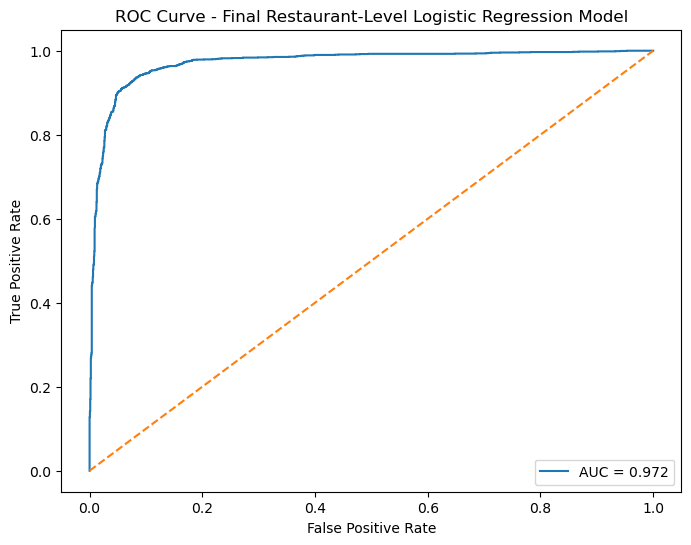

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Restaurant-Level Logistic Regression Model")
plt.legend()
plt.show()